# 다변수 미분가능성의 심상-10강 4기 25강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, h, t = sp.symbols("x y h t", real=True)

## 3. 심상 하나 — 일변수 미분가능성
부드러운 곡선 위 한 점에서 **할선의 기울기**가 $h\to 0$ 일 때 **접선의 기울기(미분계수)** 로 수렴합니다.
$\displaystyle f'(a)=\lim_{h\to 0}\frac{f(a+h)-f(a)}{h}$, 그리고 이 극한이 존재하면 $\lim_{x\to a}f(x)=f(a)$ (미분가능 $\Rightarrow$ 연속).

In [2]:
f = x**2          # 부드러운 곡선
a = sp.Rational(1, 1)
secant = (f.subs(x, a + h) - f.subs(x, a)) / h
print("secant slope (h!=0)         :", sp.simplify(secant))
print("limit h->0  = f'(a)         :", sp.limit(secant, h, 0))
print("f'(x) by diff               :", sp.diff(f, x))
print("f'(a) at a=1                :", sp.diff(f, x).subs(x, a))
# 미분가능 => 연속: f(x)-f(a) = (secant)*(x-a) -> 0
print("lim_{x->a} f(x)-f(a)        :", sp.limit(f - f.subs(x, a), x, a), "(continuity follows)")

secant slope (h!=0)         : h + 2
limit h->0  = f'(a)         : 2
f'(x) by diff               : 2*x
f'(a) at a=1                : 2
lim_{x->a} f(x)-f(a)        : 0 (continuity follows)


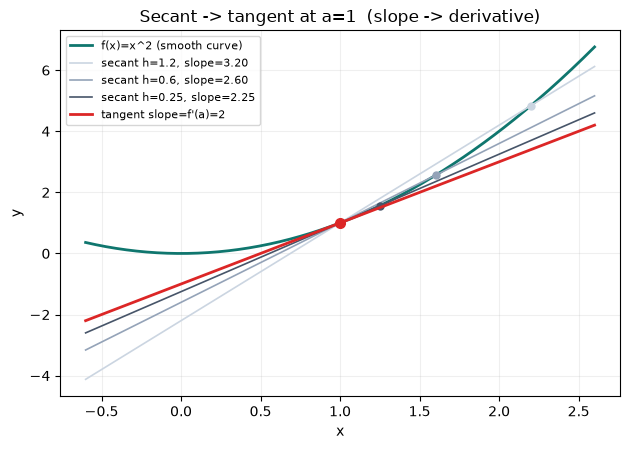

In [3]:
# secant -> tangent 그림 (모든 텍스트는 ASCII)
fl = sp.lambdify(x, f, "numpy")
a0 = 1.0
xs = np.linspace(-0.6, 2.6, 400)
fpa = float(sp.diff(f, x).subs(x, a0))           # 접선 기울기 = 2
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(xs, fl(xs), color="#0f766e", lw=2, label="f(x)=x^2 (smooth curve)")
for hh, col in [(1.2, "#cbd5e1"), (0.6, "#94a3b8"), (0.25, "#475569")]:
    m = (fl(a0 + hh) - fl(a0)) / hh
    ax.plot(xs, fl(a0) + m * (xs - a0), color=col, lw=1.2,
            label=f"secant h={hh}, slope={m:.2f}")
    ax.plot([a0 + hh], [fl(a0 + hh)], "o", color=col, ms=5)
ax.plot(xs, fl(a0) + fpa * (xs - a0), color="#dc2626", lw=2,
        label=f"tangent slope=f'(a)={fpa:.0f}")
ax.plot([a0], [fl(a0)], "o", color="#dc2626", ms=7)
ax.set_title("Secant -> tangent at a=1  (slope -> derivative)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.2)
fig.tight_layout(); plt.show()

## 4. 심상 둘 — 내적은 직교 정사영
내적은 두 벡터를 받아 실수 하나를 뱉는 함수입니다. $\langle a,b\rangle=\|a\|\,(\text{b를 a에 정사영한 길이})=\|a\|\|b\|\cos\theta$.
여기서 **노름** $\|a\|=\sqrt{\langle a,a\rangle}$, **각도** $\cos\theta=\dfrac{\langle a,b\rangle}{\|a\|\|b\|}$ 가 따라 나옵니다.

In [4]:
def ip(u, v):    return float(np.dot(u, v))
def norm(v):     return np.sqrt(ip(v, v))
def angle_deg(u, v):
    return np.degrees(np.arccos(np.clip(ip(u, v) / (norm(u) * norm(v)), -1, 1)))

a_vec, b_vec = np.array([3.0, 1.0]), np.array([1.0, 2.0])
proj_len = ip(a_vec, b_vec) / norm(a_vec)          # b를 a에 정사영한 길이
print(f"<a,b>                 = {ip(a_vec, b_vec):.4f}")
print(f"|a| * proj_len        = {norm(a_vec):.4f} * {proj_len:.4f} = {norm(a_vec) * proj_len:.4f}")
print(f"|a||b|cos(theta)      = {norm(a_vec) * norm(b_vec) * np.cos(np.radians(angle_deg(a_vec, b_vec))):.4f}")
print(f"|a| = sqrt(<a,a>)     = {norm(a_vec):.4f}  (=sqrt({ip(a_vec, a_vec):.0f}))")
print(f"angle theta           = {angle_deg(a_vec, b_vec):.2f} deg")

<a,b>                 = 5.0000
|a| * proj_len        = 3.1623 * 1.5811 = 5.0000
|a||b|cos(theta)      = 5.0000
|a| = sqrt(<a,a>)     = 3.1623  (=sqrt(10))
angle theta           = 45.00 deg


## 6. 방향미분과 함정 — 직선만으로는 부족하다
방향 $d=(d_1,d_2),\ \|d\|=1$ 마다 $\displaystyle D_d f(P)=\lim_{h\to 0}\frac{f(P+hd)-f(P)}{h}$.
노트의 반례: $y$축에서 $f=0$, 그 밖에서 $f=1$. 원점을 지나는 **모든 직선** 에서 방향미분은 $0$이지만 원점에서 **불연속**입니다.

In [5]:
# 매끈한 함수에서는 방향미분 = <grad f, d>
P = sp.Matrix([1, 2])
d1, d2 = sp.symbols("d1 d2", real=True)
g = x**2 + x*y + 2*y**2                              # 매끈한 예시
gx, gy = sp.diff(g, x), sp.diff(g, y)
grad_P = sp.Matrix([gx.subs({x: P[0], y: P[1]}), gy.subs({x: P[0], y: P[1]})])
gline = g.subs({x: P[0] + h*d1, y: P[1] + h*d2})
Dd = sp.limit((gline - g.subs({x: P[0], y: P[1]})) / h, h, 0)
print("grad g(P)                    :", list(grad_P))
print("D_d g(P) via limit           :", sp.expand(Dd))
print("<grad g(P), d>               :", sp.expand((grad_P.T * sp.Matrix([d1, d2]))[0]))
print("equal for smooth g ?         :", sp.simplify(Dd - (grad_P.T * sp.Matrix([d1, d2]))[0]) == 0)

grad g(P)                    : [4, 9]
D_d g(P) via limit           : 4*d1 + 9*d2
<grad g(P), d>               : 4*d1 + 9*d2
equal for smooth g ?         : True


In [6]:
# 반례: y축에서 0, 그 밖 1 -> 모든 직선 방향미분 = 0 인데 불연속
def f_counter(px, py):
    return np.where(np.isclose(px, 0.0), 0.0, 1.0)

print("All STRAIGHT-line directional derivatives at origin:")
for ang in [0, 30, 45, 90, 120, 135]:                # 90도(=y축 방향) 포함, 임의 각도
    th = np.radians(ang)
    d = np.array([np.cos(th), np.sin(th)])
    hs = np.array([1e-1, 1e-2, 1e-3, 1e-4])
    diffq = (f_counter(hs * d[0], hs * d[1]) - f_counter(0.0, 0.0)) / hs
    print(f"  dir {ang:3d} deg : (f(hd)-f(0))/h = {diffq}  -> D_d f(0) = 0")
# 그런데 y축을 따라 곡선으로 휘어 들어가면(x=eps^2, y=eps) f=1 로 점프 -> 불연속
eps = np.array([1e-1, 1e-2, 1e-3])
print("curved path (x=eps^2, y=eps) -> f =", f_counter(eps**2, eps), "  (stays 1, jumps from f(0)=0)")
print("=> every straight-line D_d f(0)=0, but f is NOT continuous at origin.")

All STRAIGHT-line directional derivatives at origin:
  dir   0 deg : (f(hd)-f(0))/h = [   10.   100.  1000. 10000.]  -> D_d f(0) = 0
  dir  30 deg : (f(hd)-f(0))/h = [   10.   100.  1000. 10000.]  -> D_d f(0) = 0
  dir  45 deg : (f(hd)-f(0))/h = [   10.   100.  1000. 10000.]  -> D_d f(0) = 0
  dir  90 deg : (f(hd)-f(0))/h = [0. 0. 0. 0.]  -> D_d f(0) = 0
  dir 120 deg : (f(hd)-f(0))/h = [   10.   100.  1000. 10000.]  -> D_d f(0) = 0
  dir 135 deg : (f(hd)-f(0))/h = [   10.   100.  1000. 10000.]  -> D_d f(0) = 0
curved path (x=eps^2, y=eps) -> f = [1. 1. 1.]   (stays 1, jumps from f(0)=0)
=> every straight-line D_d f(0)=0, but f is NOT continuous at origin.


## 7. 올바른 정의 — 임의의 곡선 경로까지
매끈한 함수는 노름 극한 $\displaystyle\lim_{\|K\|\to 0}\frac{\|f(P+K)-f(P)-\langle\nabla f(P),K\rangle\|}{\|K\|}=0$ 을 만족합니다.
반례 함수 $f$ 는 같은 극한이 임의 경로에서 $0$으로 가지 않으므로 미분가능하지 않습니다.

In [7]:
# 매끈한 g 에 대해 노름 극한이 0 으로 가는지 수치 확인
g_np = sp.lambdify((x, y), g, "numpy")
gradP = np.array([float(grad_P[0]), float(grad_P[1])])
Pn = np.array([1.0, 2.0])
print("Differentiability residual for smooth g (should -> 0):")
rng = np.random.default_rng(0)
for r in [1e-1, 1e-2, 1e-3, 1e-4]:
    th = rng.uniform(0, 2*np.pi, 2000)
    K = r * np.column_stack([np.cos(th), np.sin(th)])
    num = np.abs(g_np(Pn[0] + K[:, 0], Pn[1] + K[:, 1]) - g_np(*Pn) - K @ gradP)
    print(f"  |K|={r:6.0e}:  max residual / |K| = {np.max(num / r):.3e}")

Differentiability residual for smooth g (should -> 0):
  |K|= 1e-01:  max residual / |K| = 2.207e-01
  |K|= 1e-02:  max residual / |K| = 2.207e-02
  |K|= 1e-03:  max residual / |K| = 2.207e-03
  |K|= 1e-04:  max residual / |K| = 2.207e-04


In [8]:
# 반례 함수의 노름 극한은 0 으로 가지 않는다 (y축 근처 경로가 잔차를 1 가까이 유지)
print("Same residual test for the counterexample f (does NOT -> 0):")
for r in [1e-1, 1e-2, 1e-3]:
    th = np.linspace(0, 2*np.pi, 4000)
    K = r * np.column_stack([np.cos(th), np.sin(th)])
    # 반례는 grad 가 0 (모든 직선 방향미분=0) 이므로 잔차 = |f(P+K)-f(0)|
    num = np.abs(f_counter(K[:, 0], K[:, 1]) - f_counter(0.0, 0.0))
    print(f"  |K|={r:6.0e}:  max residual / |K| = {np.max(num / r):.3e}  (blows up)")

Same residual test for the counterexample f (does NOT -> 0):
  |K|= 1e-01:  max residual / |K| = 1.000e+01  (blows up)
  |K|= 1e-02:  max residual / |K| = 1.000e+02  (blows up)
  |K|= 1e-03:  max residual / |K| = 1.000e+03  (blows up)


## 8. 그래디언트는 왜 내적으로 들어오나
방향미분은 방향(벡터)을 받아 값을 뱉는 **코벡터(미분형식)** 이고, 표준내적으로 표현한 벡터가 **그래디언트** 입니다.
표준내적에서 코벡터 $d\mapsto D_d f(P)$ 의 리스 표현은 $\nabla f(P)=\big(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y}\big)$ 이고,
그래디언트는 가장 가파른 증가 방향, 방향미분의 최댓값은 $\|\nabla f(P)\|$ 입니다.

In [9]:
# 코벡터 D_d f(P) 는 d 에 선형: 표준기저로 행벡터(코벡터) 성분을 읽으면 그래디언트
e1, e2 = sp.Matrix([1, 0]), sp.Matrix([0, 1])
covec = sp.Matrix([[Dd.subs({d1: 1, d2: 0})], [Dd.subs({d1: 0, d2: 1})]])
print("covector components (D_e1 f, D_e2 f) :", list(covec), "== grad g(P) :", list(grad_P))
# 방향미분 최댓값 = ||grad|| 는 grad 방향에서 달성
unit_grad = gradP / np.linalg.norm(gradP)
print("max D_d g(P) over ||d||=1            :", float(np.dot(gradP, unit_grad)), "= ||grad g(P)|| =", float(np.linalg.norm(gradP)))

covector components (D_e1 f, D_e2 f) : [4, 9] == grad g(P) : [4, 9]
max D_d g(P) over ||d||=1            : 9.848857801796106 = ||grad g(P)|| = 9.848857801796104


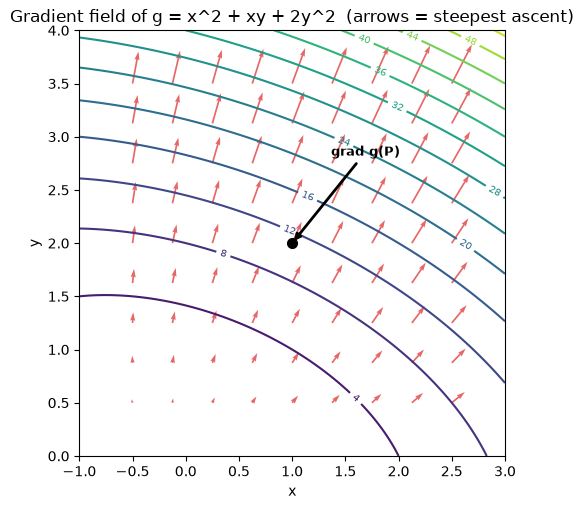

In [10]:
# 매끈한 g 의 등고선 + 그래디언트(가파른 증가) 화살표
gx_np = sp.lambdify((x, y), gx, "numpy")
gy_np = sp.lambdify((x, y), gy, "numpy")
X, Y = np.meshgrid(np.linspace(-1, 3, 400), np.linspace(0, 4, 400))
fig, ax = plt.subplots(figsize=(6.0, 5.2))
cs = ax.contour(X, Y, g_np(X, Y), levels=14, cmap="viridis")
ax.clabel(cs, inline=True, fontsize=7)
Xs, Ys = np.meshgrid(np.linspace(-0.5, 2.5, 9), np.linspace(0.5, 3.5, 9))
ax.quiver(Xs, Ys, gx_np(Xs, Ys), gy_np(Xs, Ys), color="#dc2626", alpha=0.7, width=0.004)
ax.plot(*Pn, "o", color="black", ms=7)
ax.annotate("grad g(P)", Pn, Pn + gradP / np.linalg.norm(gradP) * 0.9,
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2), fontsize=9, weight="bold")
ax.set_title("Gradient field of g = x^2 + xy + 2y^2  (arrows = steepest ascent)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
fig.tight_layout(); plt.show()